In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df=pd.read_excel(r"D:\SLA\PROJECTS\Sports_data.xlsx")
df.head()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
0,basketball,1,Sabrina Glenn,24,195,108,Center,ACL Tear,Severe,Physiotherapy,7,0,2017-12-19,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747
1,basketball,2,Brenda Weber,32,183,87,Forward,Ankle Sprain,Mild,Physiotherapy,8,1,2017-08-10,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661
2,basketball,3,Tamara Guzman,28,208,109,Center,Knee Injury,Moderate,Flexibility Exercises,3,0,2018-11-21,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761
3,basketball,4,Meredith Russell,25,196,70,Forward,Shoulder Dislocation,Moderate,Strength Training,11,1,2017-07-18,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154
4,basketball,5,Bruce Jones,24,178,80,Guard,Shoulder Dislocation,Moderate,Balance Training,3,0,2015-03-05,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877


In [3]:
df.tail()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
9595,Gym,1080,Chris Elliott,25,191,91,Center,Rotator Cuff Injury,Moderate,Physiotherapy,7,1,2013-12-29,0.745913,61.423338,69.822917,58.739437,62.926583,68.880680
9596,Gym,7980,Kevin Baker,32,198,51,Batsman,Elbow Pain,Mild,Physiotherapy,5,0,2020-06-02,0.873331,81.576909,91.082987,52.653274,67.128295,74.181400
9597,Gym,1116,Nicole Nguyen,25,190,92,Forward,Tendonitis,Severe,Balance Training,6,1,2020-03-19,0.742516,62.339017,67.609491,61.131492,63.132485,67.130565
9598,Gym,6094,Linda Humphrey,38,168,83,Doubles,Elbow Pain,Severe,Flexibility Exercises,5,0,2015-04-04,0.957539,38.154820,54.802039,61.843169,69.406282,74.953008
9599,Gym,6833,Tina Wallace,21,172,72,Bowler,Tendonitis,Moderate,Physiotherapy,9,0,2017-04-12,0.825992,71.155416,82.309194,79.322377,57.861403,93.898373


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Sport                            9600 non-null   object        
 1   Player_ID                        9600 non-null   int64         
 2   PLAYER_NAME                      9600 non-null   object        
 3   Age                              9600 non-null   int64         
 4   Height_cm                        9600 non-null   int64         
 5   Weight_kg                        9600 non-null   int64         
 6   Position / Exercise_Type         9600 non-null   object        
 7   Injury_Type                      9600 non-null   object        
 8   Injury_Severity                  9600 non-null   object        
 9   Rehabilitation_Program           9600 non-null   object        
 10  Rehabilitation_Time_weeks        9600 non-null   int64      

In [5]:
df.describe()

,Player_ID,Age,Height_cm,Weight_kg,Rehabilitation_Time_weeks,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
count,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,3994.420729,27.465521,181.280625,83.183021,7.118750,0.485729,0.768938,57.580790,61.435204,63.076183,34.106983,183.308146
std,2314.652256,3.713999,9.312171,11.927829,1.807793,0.499822,0.079867,10.161453,15.354834,11.242822,28.901452,118.484784
min,1.000000,18.000000,152.000000,50.000000,1.000000,0.000000,0.500507,20.030000,10.120000,21.680000,3.020000,30.009563
25%,1979.000000,25.000000,172.000000,73.000000,6.000000,0.000000,0.742877,53.418826,46.521222,60.019243,5.827500,67.350066
50%,3997.500000,27.000000,184.000000,88.000000,7.000000,0.000000,0.782565,56.313933,62.839625,62.524435,40.063890,99.345626
75%,5999.250000,29.000000,189.000000,91.000000,8.000000,1.000000,0.799285,61.117161,68.868281,65.109942,63.825224,301.409019
max,8000.000000,39.000000,209.000000,119.000000,15.000000,1.000000,1.000000,99.297216,99.964742,99.980831,98.908153,399.500000


In [6]:
df.size

182400

In [7]:
df.shape

(9600, 19)

In [8]:
df.dtypes

Sport                                      object
Player_ID                                   int64
PLAYER_NAME                                object
Age                                         int64
Height_cm                                   int64
Weight_kg                                   int64
Position / Exercise_Type                   object
Injury_Type                                object
Injury_Severity                            object
Rehabilitation_Program                     object
Rehabilitation_Time_weeks                   int64
Injury_Recurrence                           int64
Date_of_Injury                     datetime64[ns]
Rehabilitation_Efficiency_Score           float64
Knee_Angle_deg                            float64
Jump_Height_cm                            float64
Ankle_Flexion_deg                         float64
Speed_m_s                                 float64
Reaction_Time_ms                          float64
dtype: object

In [9]:
df.nunique()

Sport                                 6
Player_ID                          8000
PLAYER_NAME                        7828
Age                                  22
Height_cm                            56
Weight_kg                            69
Position / Exercise_Type             12
Injury_Type                          17
Injury_Severity                       3
Rehabilitation_Program                4
Rehabilitation_Time_weeks            15
Injury_Recurrence                     2
Date_of_Injury                     3698
Rehabilitation_Efficiency_Score    7841
Knee_Angle_deg                     7997
Jump_Height_cm                     7998
Ankle_Flexion_deg                  7999
Speed_m_s                          7978
Reaction_Time_ms                   7998
dtype: int64

In [10]:
df.columns

Index(['Sport', 'Player_ID', 'PLAYER_NAME', 'Age', 'Height_cm', 'Weight_kg',
       'Position / Exercise_Type', 'Injury_Type', 'Injury_Severity',
       'Rehabilitation_Program', 'Rehabilitation_Time_weeks',
       'Injury_Recurrence', 'Date_of_Injury',
       'Rehabilitation_Efficiency_Score', 'Knee_Angle_deg', 'Jump_Height_cm',
       'Ankle_Flexion_deg', 'Speed_m_s', 'Reaction_Time_ms'],
      dtype='object')

In [11]:
df.isnull().sum()

Sport                              0
Player_ID                          0
PLAYER_NAME                        0
Age                                0
Height_cm                          0
Weight_kg                          0
Position / Exercise_Type           0
Injury_Type                        0
Injury_Severity                    0
Rehabilitation_Program             0
Rehabilitation_Time_weeks          0
Injury_Recurrence                  0
Date_of_Injury                     0
Rehabilitation_Efficiency_Score    0
Knee_Angle_deg                     0
Jump_Height_cm                     0
Ankle_Flexion_deg                  0
Speed_m_s                          0
Reaction_Time_ms                   0
dtype: int64

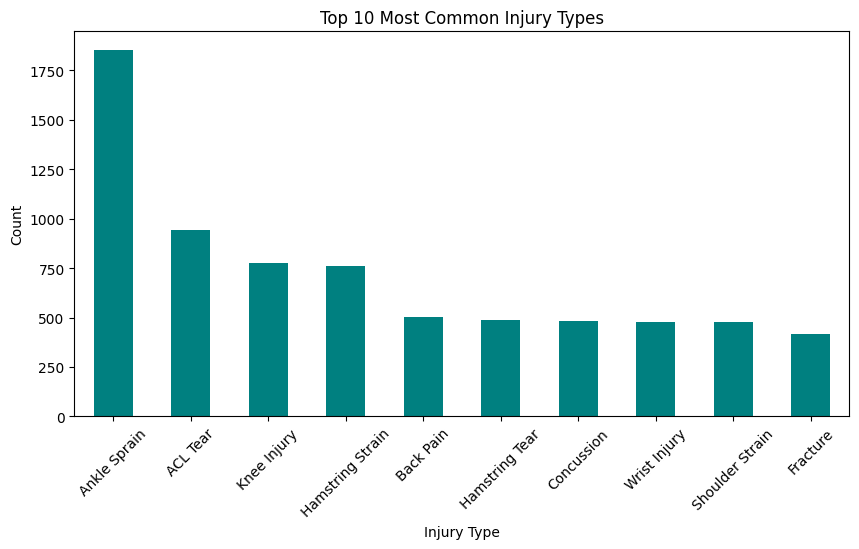

In [12]:
# Distribution of most common injury types among players
plt.figure(figsize=(10,5))
df['Injury_Type'].value_counts().nlargest(10).plot(kind='bar', color='teal')

plt.title("Top 10 Most Common Injury Types")
plt.xlabel("Injury Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

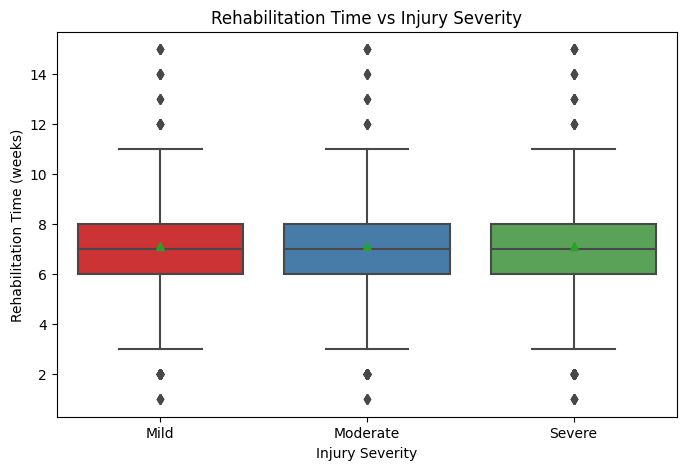

In [13]:
# Relationship between injury severity and rehabilitation duration
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Injury_Severity',
    y='Rehabilitation_Time_weeks',
    data=df,
    order=['Mild', 'Moderate', 'Severe'],
    palette='Set1',
    showmeans=True
)

plt.title("Rehabilitation Time vs Injury Severity")
plt.xlabel("Injury Severity")
plt.ylabel("Rehabilitation Time (weeks)")

plt.show()


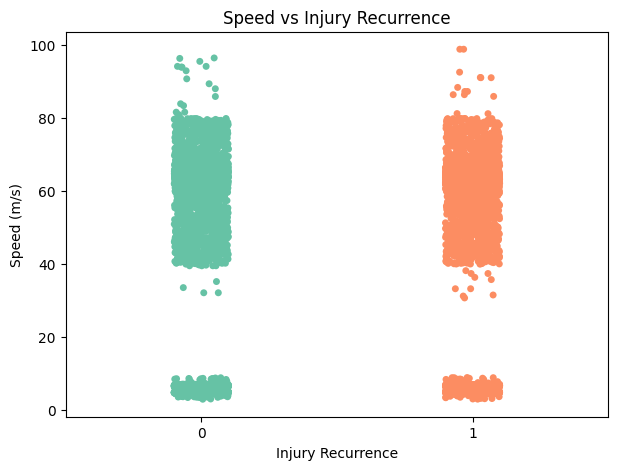

In [14]:
# Relationship between speed and injury recurrence
plt.figure(figsize=(7,5))
sns.stripplot(x='Injury_Recurrence', y='Speed_m_s', 
              data=df, hue='Injury_Recurrence', palette='Set2')

plt.title("Speed vs Injury Recurrence")
plt.xlabel("Injury Recurrence")
plt.ylabel("Speed (m/s)")

plt.legend().remove()
plt.show()

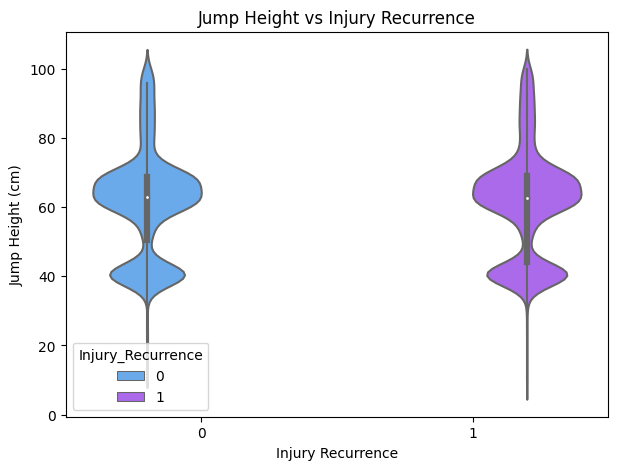

In [15]:
# Distribution of jump height based on injury recurrence status
plt.figure(figsize=(7,5))
sns.violinplot(
    x='Injury_Recurrence',
    y='Jump_Height_cm',
    hue='Injury_Recurrence',
    data=df,
    palette='cool',
    legend=False
)

plt.title("Jump Height vs Injury Recurrence")
plt.xlabel("Injury Recurrence")
plt.ylabel("Jump Height (cm)")
plt.show()

In [16]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Player_ID,Age,Height_cm,Weight_kg,Rehabilitation_Time_weeks,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
Player_ID,1.000000,0.247799,-0.514093,-0.487472,0.026152,0.003834,0.001056,-0.031245,-0.001075,0.130997,-0.060333,0.000892
Age,0.247799,1.000000,-0.094568,-0.064284,0.046041,0.004000,0.032273,-0.083768,0.009756,0.047127,-0.206124,0.191415
Height_cm,-0.514093,-0.094568,1.000000,0.474450,-0.156391,-0.013599,-0.105457,0.120198,0.424682,-0.069676,0.380608,-0.353488
Weight_kg,-0.487472,-0.064284,0.474450,1.000000,-0.112133,-0.009531,-0.022563,0.044361,0.305206,-0.065424,0.214069,-0.189209
Rehabilitation_Time_weeks,0.026152,0.046041,-0.156391,-0.112133,1.000000,0.001184,0.090631,-0.071054,-0.271499,0.005019,-0.351816,0.350918
Injury_Recurrence,0.003834,0.004000,-0.013599,-0.009531,0.001184,1.000000,0.013844,0.013308,-0.007523,-0.012775,-0.005592,0.004736
Rehabilitation_Efficiency_Score,0.001056,0.032273,-0.105457,-0.022563,0.090631,0.013844,1.000000,-0.052345,-0.203306,0.018537,-0.287104,0.286842
Knee_Angle_deg,-0.031245,-0.083768,0.120198,0.044361,-0.071054,0.013308,-0.052345,1.000000,0.194672,-0.004860,0.272062,-0.284325
Jump_Height_cm,-0.001075,0.009756,0.424682,0.305206,-0.271499,-0.007523,-0.203306,0.194672,1.000000,0.001821,0.655613,-0.674960
Ankle_Flexion_deg,0.130997,0.047127,-0.069676,-0.065424,0.005019,-0.012775,0.018537,-0.004860,0.001821,1.000000,-0.021527,0.027470


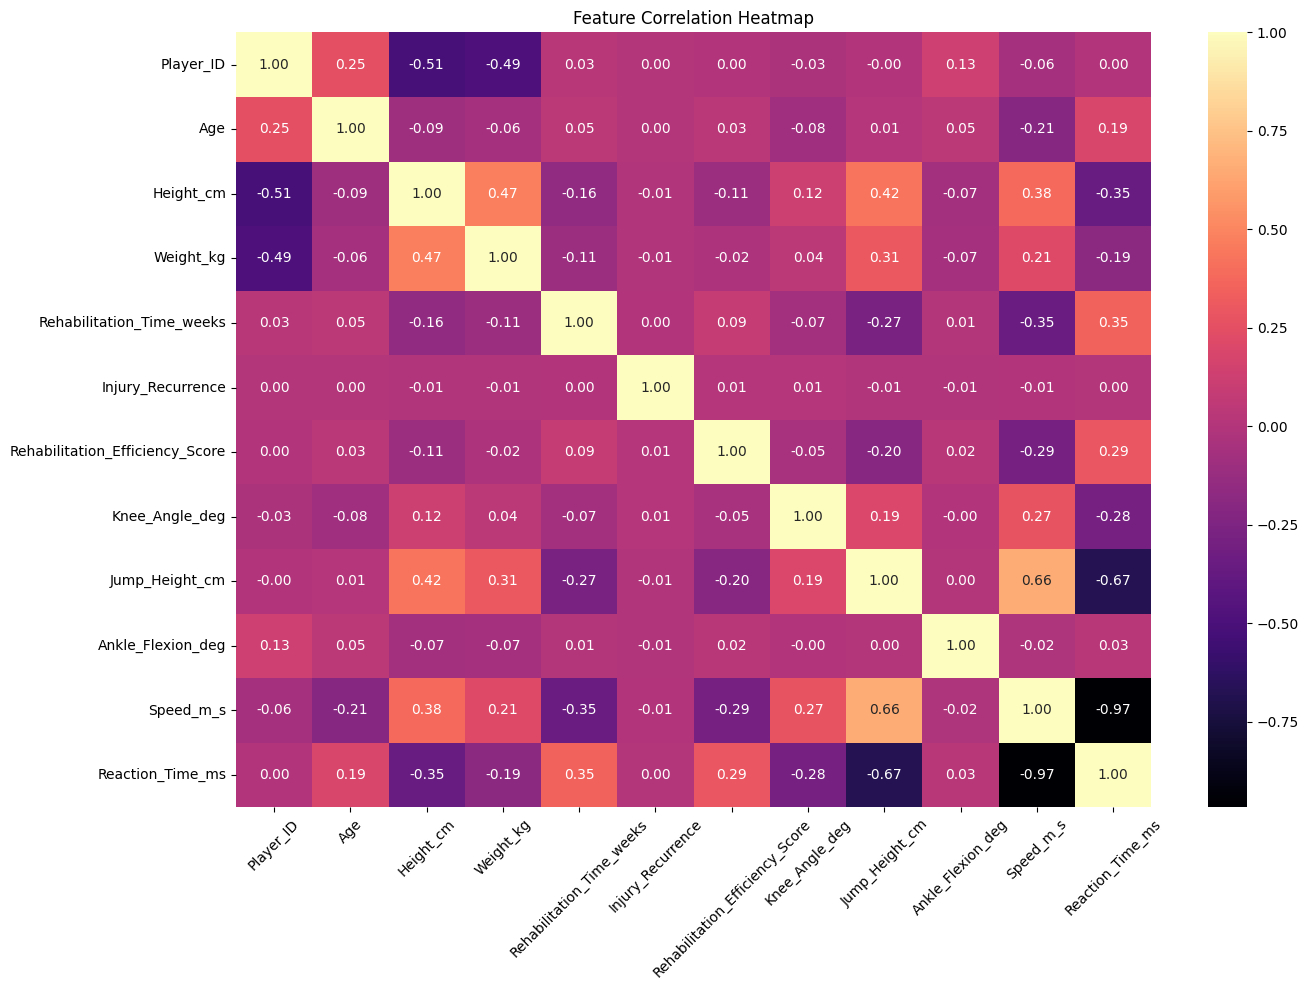

In [17]:
# Correlation analysis of numerical performance and injury related features
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True),cmap='magma',annot=True,fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
#Feature Engineering

In [19]:
df['BMI'] = df['Weight_kg'] / ((df['Height_cm'] / 100) ** 2)
df['Power_Index'] = df['Jump_Height_cm'] * df['Speed_m_s']
df['Strength_Index'] = df['Weight_kg'] / df['Height_cm']
df['Agility_Index'] = df['Speed_m_s'] / (df['Reaction_Time_ms'] + 1)

In [20]:
df.head()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,...,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms,BMI,Power_Index,Strength_Index,Agility_Index
0,basketball,1,Sabrina Glenn,24,195,108,Center,ACL Tear,Severe,Physiotherapy,...,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747,28.402367,4396.440682,0.553846,0.866973
1,basketball,2,Brenda Weber,32,183,87,Forward,Ankle Sprain,Mild,Physiotherapy,...,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661,25.978680,5935.015323,0.475410,1.534283
2,basketball,3,Tamara Guzman,28,208,109,Center,Knee Injury,Moderate,Flexibility Exercises,...,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761,25.194157,3496.153539,0.524038,0.486979
3,basketball,4,Meredith Russell,25,196,70,Forward,Shoulder Dislocation,Moderate,Strength Training,...,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154,18.221574,4643.258142,0.357143,0.759037
4,basketball,5,Bruce Jones,24,178,80,Guard,Shoulder Dislocation,Moderate,Balance Training,...,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877,25.249337,3450.831488,0.449438,1.737531


In [21]:
columns_to_drop = [
    'Player_ID',
    'PLAYER_NAME',
    'Date_of_Injury',
    'Reaction_Time_ms',# due to high correlation with Speed
    'Rehabilitation_Time_weeks'    
]

In [22]:
df = df.drop(columns=columns_to_drop)

In [23]:
df['Injury_Recurrence'].value_counts(normalize=True)

0    0.514271
1    0.485729
Name: Injury_Recurrence, dtype: float64

In [24]:
#Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Injury_Severity'] = le.fit_transform(df['Injury_Severity'])

In [26]:
df = pd.get_dummies(df, columns=[
    'Sport',
    'Position / Exercise_Type',
    'Injury_Type',
    'Rehabilitation_Program'
], drop_first=True)

In [27]:
df.head()

,Age,Height_cm,Weight_kg,Injury_Severity,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,...,Injury_Type_Muscle Strain,Injury_Type_Rotator Cuff Injury,Injury_Type_Shoulder Dislocation,Injury_Type_Shoulder Injury,Injury_Type_Shoulder Strain,Injury_Type_Tendonitis,Injury_Type_Wrist Injury,Rehabilitation_Program_Flexibility Exercises,Rehabilitation_Program_Physiotherapy,Rehabilitation_Program_Strength Training
0,24,195,108,2,0,0.862860,78.327638,77.705191,37.926663,56.578469,...,0,0,0,0,0,0,0,0,1,0
1,32,183,87,0,1,0.806708,32.751850,83.215950,98.938884,71.320646,...,0,0,0,0,0,0,0,0,1,0
2,28,208,109,1,0,0.709122,85.958728,71.694712,88.722866,48.764455,...,0,0,0,0,0,0,0,1,0,0
3,25,196,70,1,1,0.966364,73.953027,63.010333,38.726388,73.690424,...,0,0,1,0,0,0,0,0,0,1
4,24,178,80,1,0,0.933032,35.723132,58.828864,94.458932,58.658816,...,0,0,1,0,0,0,0,0,0,0


In [28]:
from sklearn.model_selection import train_test_split
X = df.drop('Injury_Recurrence', axis=1)
y = df['Injury_Recurrence']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [31]:
X_train_raw, X_test_raw = X_train.copy(), X_test.copy()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [32]:
print("Mean:", np.mean(X_train_scaled, axis=0))
print("Std:", np.std(X_train_scaled, axis=0))

Mean: [ 1.89478063e-16  1.34608374e-15 -4.97379915e-16  4.14483263e-17
  9.51337774e-16 -2.21057740e-16 -2.39808173e-16 -3.86851045e-16
 -3.94745964e-17 -1.53950926e-16 -7.69754630e-17 -9.45910017e-16
  1.30266168e-16  0.00000000e+00 -6.31593543e-17 -3.20731096e-17
  7.50017332e-17  6.80936788e-17  2.92358730e-17 -1.01153653e-17
  3.94745964e-17  4.93432455e-17  5.03301104e-17 -3.94745964e-17
 -5.03301104e-17 -7.32747196e-17 -2.61519201e-17  1.28292438e-17
  1.38161088e-17 -1.52964061e-17 -4.63826508e-17  5.03301104e-17
  2.17110280e-17  7.94426253e-17  4.93432455e-18  4.73695157e-17
 -9.86864911e-18 -5.08235429e-17 -1.57898386e-17 -1.38161088e-17
 -2.86190824e-17  1.28292438e-17  2.93592311e-17 -6.51330841e-17
 -4.14483263e-17 -1.28292438e-17 -8.38835174e-18  3.94745964e-17]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [33]:
 rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train_raw, y_train)
y_pred_rf = rf_model.predict(X_test_raw)
rf_score = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_score)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5583333333333333
              precision    recall  f1-score   support

           0       0.56      0.67      0.61      1234
           1       0.56      0.44      0.49      1166

    accuracy                           0.56      2400
   macro avg       0.56      0.55      0.55      2400
weighted avg       0.56      0.56      0.55      2400



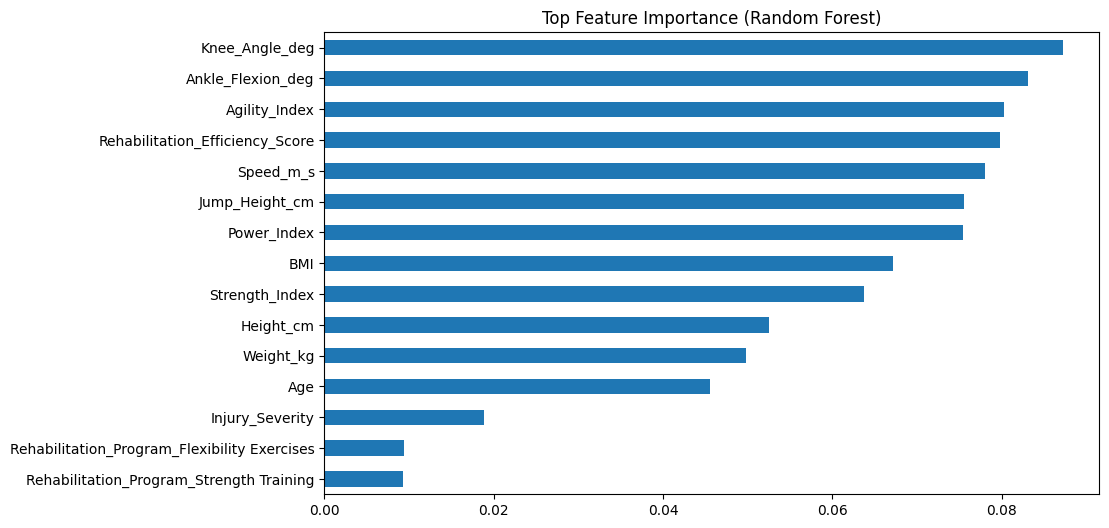

In [34]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='barh')
plt.title("Top Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

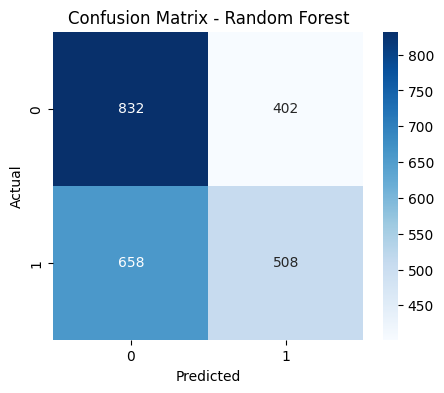

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_raw, y_train)
y_pred_dt = dt_model.predict(X_test_raw)
dt_score = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_score)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6054166666666667
              precision    recall  f1-score   support

           0       0.62      0.61      0.61      1234
           1       0.59      0.60      0.60      1166

    accuracy                           0.61      2400
   macro avg       0.61      0.61      0.61      2400
weighted avg       0.61      0.61      0.61      2400



In [37]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

nb_score = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_score)
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.48791666666666667
              precision    recall  f1-score   support

           0       0.50      0.38      0.44      1234
           1       0.48      0.60      0.53      1166

    accuracy                           0.49      2400
   macro avg       0.49      0.49      0.48      2400
weighted avg       0.49      0.49      0.48      2400



In [38]:
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_score = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_score)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5020833333333333
              precision    recall  f1-score   support

           0       0.51      0.63      0.57      1234
           1       0.48      0.36      0.41      1166

    accuracy                           0.50      2400
   macro avg       0.50      0.50      0.49      2400
weighted avg       0.50      0.50      0.49      2400



In [39]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train_raw, y_train)

y_pred_gb = gb_model.predict(X_test_raw)

gb_score = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_score)
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.5433333333333333
              precision    recall  f1-score   support

           0       0.55      0.61      0.58      1234
           1       0.53      0.47      0.50      1166

    accuracy                           0.54      2400
   macro avg       0.54      0.54      0.54      2400
weighted avg       0.54      0.54      0.54      2400



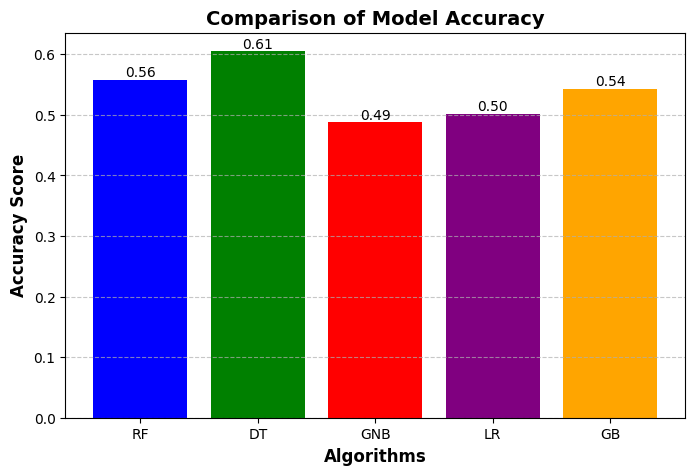

In [40]:
# Define algorithms and their corresponding scores
algorithms = ["RF", "DT", "GNB", "LR", "GB"]
scores = [rf_score, dt_score, nb_score, lr_score, gb_score]

# Set up the figure and axis
plt.figure(figsize=(8,5))
bars = plt.bar(algorithms, scores, 
               color=['blue', 'green', 'red', 'purple', 'orange'])

# Add title and labels
plt.xlabel("Algorithms", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12, fontweight='bold')
plt.title("Comparison of Model Accuracy", fontsize=14, fontweight='bold')

# Display accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             yval, 
             f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=10)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [41]:
import pickle

In [42]:
# Save trained Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [43]:
# Load model
with open("random_forest_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [44]:
# Pose Estimation for Performance Analysis
import cv2
import mediapipe as mp

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()
mp_drawing = mp.solutions.drawing_utils

# Open video
cap = cv2.VideoCapture(r"D:\SLA\PROJECTS\Video.mp4")

# Resizable window
cv2.namedWindow("Pose Estimation", cv2.WINDOW_NORMAL)

# Initialize injury risk accumulator
total_severity = 0
frame_count = 0
smoothing_factor = 0.3

# Pause flag
is_paused = False

# Function to detect incorrect posture
def calculate_angle(a, b, c):
    a = np.array([a.x, a.y])
    b = np.array([b.x, b.y])
    c = np.array([c.x, c.y])

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)  # prevent crash

    angle = np.degrees(np.arccos(cosine_angle))
    return angle


def detect_incorrect_posture(results, sport_type='gym'):
    feedback = []
    severity = 0

    if results.pose_landmarks:
        lm = results.pose_landmarks.landmark

        left_shoulder = lm[mp_pose.PoseLandmark.LEFT_SHOULDER]
        right_shoulder = lm[mp_pose.PoseLandmark.RIGHT_SHOULDER]
        shoulder_distance = np.abs(left_shoulder.x - right_shoulder.x)

        if sport_type == 'general':
            if shoulder_distance < 0.15:
                feedback.append("Warning: Your shoulders are too close! Maintain proper posture.")
                severity += 20

        head = lm[mp_pose.PoseLandmark.NOSE]
        neck = lm[mp_pose.PoseLandmark.LEFT_SHOULDER]

        if np.abs(head.y - neck.y) > 0.1:
            feedback.append("Posture Warning: Keep your head aligned with your body.")
            severity += 25

        if sport_type == 'football':
            left_knee = lm[mp_pose.PoseLandmark.LEFT_KNEE]
            right_knee = lm[mp_pose.PoseLandmark.RIGHT_KNEE]

            knee_bend = np.abs(left_knee.x - right_knee.x)

            if knee_bend > 0.2:
                feedback.append("Knees should be more aligned. Adjust your posture.")
                severity += 30

        if sport_type == 'tennis':
            left_elbow = lm[mp_pose.PoseLandmark.LEFT_ELBOW]
            right_elbow = lm[mp_pose.PoseLandmark.RIGHT_ELBOW]

            if np.abs(left_elbow.x - right_elbow.x) > 0.2:
                feedback.append("Ensure proper arm positioning for better control.")
                severity += 15

        if sport_type == 'basketball':
            left_knee = lm[mp_pose.PoseLandmark.LEFT_KNEE]
            right_knee = lm[mp_pose.PoseLandmark.RIGHT_KNEE]

            knee_bend = np.abs(left_knee.x - right_knee.x)

            if knee_bend < 0.1:
                feedback.append("Bend your knees more for a strong stance.")
                severity += 20

        if sport_type == 'badminton':
            left_wrist = lm[mp_pose.PoseLandmark.LEFT_WRIST]
            right_wrist = lm[mp_pose.PoseLandmark.RIGHT_WRIST]

            if np.abs(left_wrist.y - right_wrist.y) > 0.15:
                feedback.append("Keep your wrists aligned for accurate shots.")
                severity += 15

        if sport_type == 'cricket':
            left_hip = lm[mp_pose.PoseLandmark.LEFT_HIP]
            right_hip = lm[mp_pose.PoseLandmark.RIGHT_HIP]

            if np.abs(left_hip.y - right_hip.y) > 0.2:
                feedback.append("Maintain a balanced hip position for stability.")
                severity += 25

        # 🔥 UPDATED: Angle-based gym logic
        if sport_type == 'gym':

            # Knee angle
            left_knee_angle = calculate_angle(
                lm[mp_pose.PoseLandmark.LEFT_HIP],
                lm[mp_pose.PoseLandmark.LEFT_KNEE],
                lm[mp_pose.PoseLandmark.LEFT_ANKLE]
            )

            right_knee_angle = calculate_angle(
                lm[mp_pose.PoseLandmark.RIGHT_HIP],
                lm[mp_pose.PoseLandmark.RIGHT_KNEE],
                lm[mp_pose.PoseLandmark.RIGHT_ANKLE]
            )

            if left_knee_angle < 160 or right_knee_angle < 160:
                feedback.append("Bend your knees properly and keep alignment stable.")
                severity += 30

        # 🔥 UPDATED: Back angle
        back_angle = calculate_angle(
            lm[mp_pose.PoseLandmark.LEFT_SHOULDER],
            lm[mp_pose.PoseLandmark.LEFT_HIP],
            lm[mp_pose.PoseLandmark.LEFT_KNEE]
        )

        if back_angle < 150:
            feedback.append("Keep your back straight and avoid excessive bending.")
            severity += 35

    if not feedback:
        feedback.append("Posture is good!")

    return feedback, severity

# Risk calculation
def calculate_injury_risk(severity):
    return min(severity, 100)


# Process video
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Resize (fix zoom)
    h, w, _ = frame.shape
    scale = 900 / w
    frame = cv2.resize(frame, (int(w * scale), int(h * scale)))

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb_frame)

    feedback, frame_severity = detect_incorrect_posture(results, sport_type='gym')

    total_severity = total_severity * (1 - smoothing_factor) + frame_severity * smoothing_factor
    injury_risk = calculate_injury_risk(total_severity)

    # Risk level
    if injury_risk < 30:
        risk_level = "LOW"
        risk_color = (0, 255, 0)
    elif injury_risk < 60:
        risk_level = "MEDIUM"
        risk_color = (0, 255, 255)
    else:
        risk_level = "HIGH"
        risk_color = (0, 0, 255)

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

    # ===== UI =====

    # Title
    cv2.putText(frame, "AI Injury Risk Analysis", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    # Feedback (MULTI-LINE FIX)
    y0, dy = 80, 45
    for i, text in enumerate(feedback):
        y = y0 + i * dy
        cv2.putText(frame, text, (10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    # Bottom UI
    h, w, _ = frame.shape

    cv2.putText(frame, f"Risk Level: {risk_level}", (10, h - 60),
                cv2.FONT_HERSHEY_SIMPLEX, 1, risk_color, 2)

    cv2.putText(frame, f"Injury Risk: {injury_risk:.2f}%", (10, h - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 1, risk_color, 2)

    cv2.imshow("Pose Estimation", frame)

    key = cv2.waitKey(10) & 0xFF

    if key == ord('q'):
        break
    elif key == 32:
        is_paused = not is_paused

        while is_paused:
            cv2.putText(frame, "Paused. Press SPACE to resume.", (10, h - 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            cv2.imshow("Pose Estimation", frame)
            key = cv2.waitKey(10) & 0xFF
            if key == 32:
                is_paused = False

cap.release()
cv2.destroyAllWindows()

## 🔍 Key Findings

- Most input features show very low correlation with Injury Recurrence
- Model performance (~50–52%) indicates weak predictive relationships
- Feature engineering (BMI, Power Index, Agility Index) did not significantly improve accuracy

## 📌 Conclusion

The low model performance is due to limited correlation between input features and the target variable, indicating a data limitation rather than a modeling issue.

## 🚀 Future Improvements

- Use real-world sports injury datasets
- Incorporate time-series or wearable sensor data
- Apply deep learning models for better pattern extraction